# Module 1: Data Pipeline

**Muc tieu:** Thu thap va chuan hoa du lieu phim, build poster URL tu TMDB.

**Output:** `data/processed/movies.csv`

**Schema:** `movie_id, title, year, genres, overview_clean, poster_url, rating, vote_count`

## 0. Cai dat thu vien

In [1]:
# Chay cell nay neu chua cai dat cac thu vien can thiet
# !pip install pandas numpy requests nltk Pillow matplotlib

## 1.1 Tai TMDB 5000 Dataset tu Kaggle

**Cach 1 (Kaggle CLI):**
```bash
kaggle datasets download -d tmdb/tmdb-movie-metadata -p ../data/raw --unzip
```

**Cach 2 (Tai tay):** Vao https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata, tai ve va giai nen vao `data/raw/`

Sau khi tai, `data/raw/` can co:
- `tmdb_5000_movies.csv`
- `tmdb_5000_credits.csv`

In [2]:
import os

raw_dir = "../data/raw"
movies_raw = os.path.join(raw_dir, "tmdb_5000_movies.csv")
credits_raw = os.path.join(raw_dir, "tmdb_5000_credits.csv")

assert os.path.exists(movies_raw), f"Khong tim thay {movies_raw} -- hay tai dataset tu Kaggle!"
assert os.path.exists(credits_raw), f"Khong tim thay {credits_raw} -- hay tai dataset tu Kaggle!"

print("Dataset da san sang!")

Dataset da san sang!


## 1.2 Load va kham pha du lieu tho

In [3]:
import pandas as pd
import numpy as np
import json
import ast

df_movies = pd.read_csv(movies_raw)
df_credits = pd.read_csv(credits_raw)

print(f"Movies shape: {df_movies.shape}")
print(f"Credits shape: {df_credits.shape}")
print(f"\nMovies columns: {df_movies.columns.tolist()}")
print(f"\nCredits columns: {df_credits.columns.tolist()}")

Movies shape: (4803, 20)
Credits shape: (4803, 4)

Movies columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits columns: ['movie_id', 'title', 'cast', 'crew']


In [4]:
df_movies.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [5]:
print("Missing values trong movies:")
print(df_movies.isnull().sum()[df_movies.isnull().sum() > 0])

Missing values trong movies:
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64


## 1.2 Parse JSON columns (genres, keywords, cast)

In [6]:
def parse_json_column(text, key='name'):
    """Parse JSON string column, tra ve list cac gia tri theo key."""
    try:
        items = ast.literal_eval(text)
        return [item[key] for item in items]
    except (ValueError, TypeError, KeyError):
        return []

df_movies['genres_list'] = df_movies['genres'].apply(parse_json_column)
df_movies['keywords_list'] = df_movies['keywords'].apply(parse_json_column)

print("Vi du genres_list:")
print(df_movies['genres_list'].head(3).tolist())

Vi du genres_list:
[['Action', 'Adventure', 'Fantasy', 'Science Fiction'], ['Adventure', 'Fantasy', 'Action'], ['Action', 'Adventure', 'Crime']]


In [7]:
# credits: lay cast (top 5) va director
# tmdb_5000_credits.csv dung cot 'movie_id', khong phai 'id'
credit_id_col = 'movie_id' if 'movie_id' in df_credits.columns else 'id'
df_credits_renamed = df_credits.rename(columns={credit_id_col: 'id'})

def get_top_cast(text, n=5):
    try:
        cast = ast.literal_eval(text)
        return [p['name'] for p in cast[:n]]
    except (ValueError, TypeError):
        return []

def get_director(text):
    try:
        crew = ast.literal_eval(text)
        for p in crew:
            if p.get('job') == 'Director':
                return p['name']
    except (ValueError, TypeError):
        pass
    return ''

df_credits_renamed['cast_list'] = df_credits_renamed['cast'].apply(get_top_cast)
df_credits_renamed['director'] = df_credits_renamed['crew'].apply(get_director)

print("Vi du cast_list:")
print(df_credits_renamed['cast_list'].head(3).tolist())

Vi du cast_list:
[['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez'], ['Johnny Depp', 'Orlando Bloom', 'Keira Knightley', 'Stellan Skarsgård', 'Chow Yun-fat'], ['Daniel Craig', 'Christoph Waltz', 'Léa Seydoux', 'Ralph Fiennes', 'Monica Bellucci']]


## 1.3 Loc phim co du: overview va genres (buoc dau)

Dataset Kaggle TMDB 5000 **khong co cot `poster_path`** — se fetch tu TMDB API o buoc 1.4.

In [8]:
df = df_movies.merge(
    df_credits_renamed[['id', 'cast_list', 'director']],
    on='id',
    how='left'
)

print(f"Truoc khi loc: {len(df)} phim")

# Chi loc theo overview va genres, KHONG loc poster_path (se fetch o buoc 1.4)
df = df[
    df['overview'].notna() & (df['overview'].str.strip() != '') &
    df['genres_list'].apply(lambda x: len(x) > 0)
].copy()

df = df.reset_index(drop=True)
print(f"Sau khi loc: {len(df)} phim")

Truoc khi loc: 4803 phim
Sau khi loc: 4771 phim


## 1.4 Fetch poster_path tu TMDB API

Dataset Kaggle khong co `poster_path` nen can goi TMDB API de lay.

**Lay TMDB API key mien phi (chi mat 2 phut):**
1. Vao https://www.themoviedb.org/ → Dang ky tai khoan
2. Vao **Settings → API → Create → Developer**
3. Copy **API Key (v3 auth)** dan vao cell duoi

In [9]:
import requests
import time
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

TMDB_API_KEY = "98a5465c967d9163c57eeb9e3978bb92"

# Kiem tra API key hop le
test_resp = requests.get(
    f"https://api.themoviedb.org/3/movie/19995?api_key={TMDB_API_KEY}",
    timeout=10
)
assert test_resp.status_code == 200, f"API key khong hop le! Status: {test_resp.status_code}"
print(f"API key hop le! Test phim: {test_resp.json()['title']}")

API key hop le! Test phim: Avatar


In [10]:
# ---- Setup cache ----
CACHE_FILE = "../data/raw/poster_paths_cache.json"

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'r') as f:
        poster_cache = json.load(f)
    print(f"Da load cache: {len(poster_cache)} phim")
else:
    poster_cache = {}
    print("Chua co cache, se fetch moi")

def fetch_poster_path(movie_id):
    movie_id_str = str(movie_id)
    if movie_id_str in poster_cache:
        return movie_id, poster_cache[movie_id_str]
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={TMDB_API_KEY}"
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code == 200:
            return movie_id, resp.json().get('poster_path', None)
        elif resp.status_code == 429:
            time.sleep(3)
            return fetch_poster_path(movie_id)
        else:
            return movie_id, None
    except Exception:
        return movie_id, None

movie_ids = df['id'].tolist()
ids_to_fetch = [mid for mid in movie_ids if str(mid) not in poster_cache]
print(f"Can fetch: {len(ids_to_fetch)} phim (da co cache: {len(poster_cache)})")

# ---- Fetch song song ----
if ids_to_fetch:
    print(f"Bat dau fetch {len(ids_to_fetch)} phim... (uoc tinh 5-10 phut)")
    completed = 0
    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(fetch_poster_path, mid): mid for mid in ids_to_fetch}
        for future in as_completed(futures):
            movie_id, poster_path = future.result()
            poster_cache[str(movie_id)] = poster_path
            completed += 1
            if completed % 200 == 0:
                with open(CACHE_FILE, 'w') as f:
                    json.dump(poster_cache, f)
                pct = completed * 100 // len(ids_to_fetch)
                print(f"  [{pct}%] {completed}/{len(ids_to_fetch)} phim")
    with open(CACHE_FILE, 'w') as f:
        json.dump(poster_cache, f)
    print(f"Hoan thanh! Cache luu tai: {CACHE_FILE}")
else:
    print("Tat ca da co trong cache!")

# ---- Gan poster_path va build poster_url ----
df['poster_path'] = df['id'].apply(lambda mid: poster_cache.get(str(mid)))
df = df[df['poster_path'].notna()].copy().reset_index(drop=True)
print(f"\nSo phim co poster_path: {len(df)}")

TMDB_IMG_BASE = "https://image.tmdb.org/t/p/w500"
df['poster_url'] = df['poster_path'].apply(
    lambda p: f"{TMDB_IMG_BASE}{p if p.startswith('/') else '/' + p}"
)
print("Vi du poster_url:")
print(df['poster_url'].head(3).tolist())

Da load cache: 4771 phim
Can fetch: 0 phim (da co cache: 4771)
Tat ca da co trong cache!

So phim co poster_path: 4752
Vi du poster_url:
['https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg', 'https://image.tmdb.org/t/p/w500/jGWpG4YhpQwVmjyHEGkxEkeRf0S.jpg', 'https://image.tmdb.org/t/p/w500/zj8ongFhtWNsVlfjOGo8pSr7PQg.jpg']


## 1.5 Chuan hoa text: lowercase, remove stopwords, lemmatize

In [11]:
import nltk
import re

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text) or text == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

print("Dang xu ly overview_clean...")
df['overview_clean'] = df['overview'].apply(clean_text)

print("\nVi du overview goc:")
print(df['overview'].iloc[0][:200])
print("\nSau khi clean:")
print(df['overview_clean'].iloc[0][:200])

Dang xu ly overview_clean...

Vi du overview goc:
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.

Sau khi clean:
century paraplegic marine dispatched moon pandora unique mission becomes torn following order protecting alien civilization


## 1.6 Xuat file movies.csv

In [12]:
# Trich xuat nam tu release_date
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Chuyen genres_list thanh JSON string
df['genres'] = df['genres_list'].apply(json.dumps)

# Tao DataFrame output theo dung schema
df_output = df[[
    'id',
    'title',
    'year',
    'genres',
    'overview_clean',
    'poster_url',
    'vote_average',
    'vote_count'
]].copy()

df_output = df_output.rename(columns={
    'id': 'movie_id',
    'vote_average': 'rating'
})

# Loc bo dong co overview_clean rong
df_output = df_output[df_output['overview_clean'].str.strip() != ''].copy()
# Loc bo dong khong co poster_url
df_output = df_output[df_output['poster_url'].notna()].copy()

# Xu ly missing values con lai
df_output['year'] = df_output['year'].fillna(0).astype(int)
df_output['rating'] = df_output['rating'].fillna(0.0)
df_output['vote_count'] = df_output['vote_count'].fillna(0).astype(int)

df_output = df_output.reset_index(drop=True)

print(f"So phim trong output: {len(df_output)}")
print(f"\nSchema:")
print(df_output.dtypes)
print(f"\nVai dong dau:")
df_output.head(3)

So phim trong output: 4752

Schema:
movie_id            int64
title                 str
year                int64
genres                str
overview_clean        str
poster_url            str
rating            float64
vote_count          int64
dtype: object

Vai dong dau:


,movie_id,title,year,genres,overview_clean,poster_url,rating,vote_count
0,19995,Avatar,2009,"[""Action"", ""Adventure"", ""Fantasy"", ""Science Fi...",century paraplegic marine dispatched moon pand...,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...,7.2,11800
1,285,Pirates of the Caribbean: At World's End,2007,"[""Adventure"", ""Fantasy"", ""Action""]",captain barbossa long believed dead come back ...,https://image.tmdb.org/t/p/w500/jGWpG4YhpQwVmj...,6.9,4500
2,206647,Spectre,2015,"[""Action"", ""Adventure"", ""Crime""]",cryptic message bond past sends trail uncover ...,https://image.tmdb.org/t/p/w500/zj8ongFhtWNsVl...,6.3,4466


In [13]:
output_path = "../data/processed/movies.csv"
df_output.to_csv(output_path, index=False)
print(f"Da luu {len(df_output)} phim vao {output_path}")

Da luu 4752 phim vao ../data/processed/movies.csv


## Test Module 1

In [14]:
import pandas as pd
import requests

df = pd.read_csv("../data/processed/movies.csv")

# Kiem tra so luong
print(f"So phim: {len(df)}")
assert len(df) >= 4500, f"Chi co {len(df)} phim, can >= 4500"
print("So phim du >= 4500")

# Kiem tra missing values
print(f"\nMissing values:")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0, "Con missing values!"
print("Khong co missing values")

# Kiem tra poster_url
assert df['poster_url'].str.startswith("https://").all(), "poster_url khong hop le!"
print("Tat ca poster_url bat dau bang https://")

# Kiem tra schema
required_cols = ['movie_id', 'title', 'year', 'genres', 'overview_clean', 'poster_url', 'rating', 'vote_count']
for col in required_cols:
    assert col in df.columns, f"Thieu cot: {col}"
print(f"Du tat ca {len(required_cols)} cot")

print("\nTat ca kiem tra PASS!")

So phim: 4752
So phim du >= 4500

Missing values:
movie_id          0
title             0
year              0
genres            0
overview_clean    0
poster_url        0
rating            0
vote_count        0
dtype: int64
Khong co missing values
Tat ca poster_url bat dau bang https://
Du tat ca 8 cot

Tat ca kiem tra PASS!


Dang kiem tra 3 poster URL dau tien...
  OK: Avatar
  OK: Pirates of the Caribbean: At World's End
  OK: Spectre


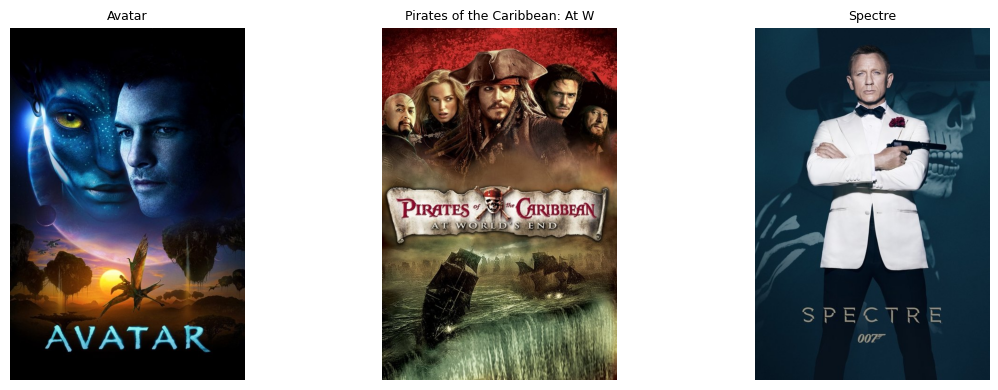


Ket qua: 3/3 poster tai thanh cong


In [15]:
# Kiem tra poster URL thuc su truy cap duoc (test 3 phim dau)
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

print("Dang kiem tra 3 poster URL dau tien...")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

success_count = 0
for i, (_, row) in enumerate(df.head(3).iterrows()):
    try:
        resp = requests.get(row['poster_url'], timeout=10)
        if resp.status_code == 200:
            img = Image.open(BytesIO(resp.content))
            axes[i].imshow(img)
            axes[i].set_title(row['title'][:30], fontsize=9)
            axes[i].axis('off')
            success_count += 1
            print(f"  OK: {row['title']}")
        else:
            axes[i].set_title(f"HTTP {resp.status_code}")
            print(f"  FAIL: {row['title']} -- HTTP {resp.status_code}")
    except Exception as e:
        axes[i].set_title("Error")
        print(f"  ERROR: {row['title']} -- {e}")

plt.tight_layout()
plt.show()
print(f"\nKet qua: {success_count}/3 poster tai thanh cong")

In [16]:
# Thong ke tong quat
import json
from collections import Counter

print("=" * 50)
print("THONG KE DATASET")
print("=" * 50)
print(f"Tong so phim:          {len(df)}")
print(f"Nam phat hanh:         {int(df['year'].min())} - {int(df['year'].max())}")
print(f"Rating trung binh:     {df['rating'].mean():.2f}")
print(f"Vote count trung binh: {df['vote_count'].mean():.0f}")

all_genres = []
for g in df['genres']:
    all_genres.extend(json.loads(g))

genre_counts = Counter(all_genres)
print(f"\nTop 10 the loai pho bien:")
for genre, count in genre_counts.most_common(10):
    print(f"  {genre:<20} {count} phim")

overview_len = df['overview_clean'].str.split().str.len()
print(f"\nDo dai overview_clean (words):")
print(f"  Min:  {overview_len.min()}")
print(f"  Max:  {overview_len.max()}")
print(f"  Mean: {overview_len.mean():.1f}")

print("\nModule 1 hoan thanh! San sang cho Module 2.")

THONG KE DATASET
Tong so phim:          4752
Nam phat hanh:         1916 - 2017
Rating trung binh:     6.13
Vote count trung binh: 698

Top 10 the loai pho bien:
  Drama                2286 phim
  Comedy               1717 phim
  Thriller             1272 phim
  Action               1152 phim
  Romance              892 phim
  Adventure            789 phim
  Crime                694 phim
  Science Fiction      532 phim
  Horror               518 phim
  Family               513 phim

Do dai overview_clean (words):
  Min:  2
  Max:  108
  Mean: 29.8

Module 1 hoan thanh! San sang cho Module 2.


Thu muc output: C:\Users\ACER\OneDrive\Desktop\KhaiPha\output


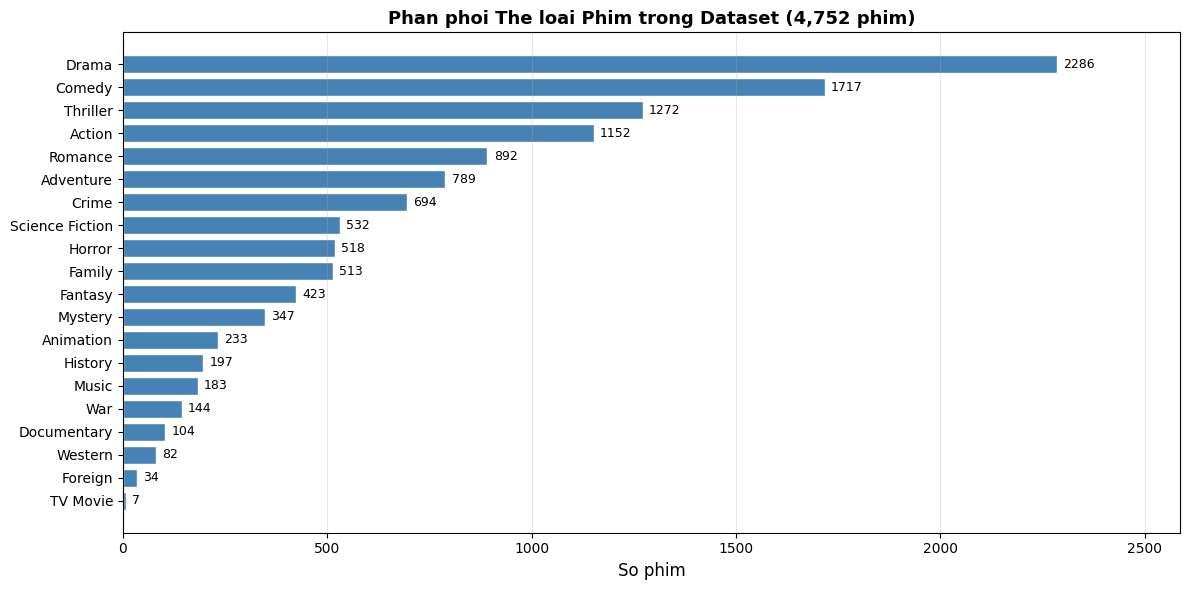

Da luu: ../output\01_genre_distribution.png


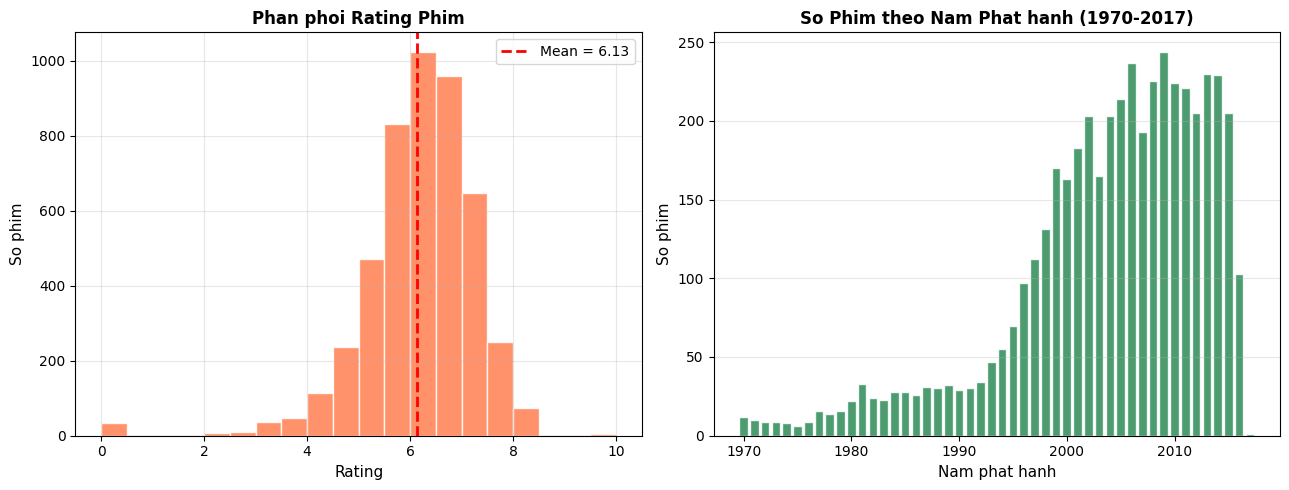

Da luu: ../output\01_rating_and_year.png


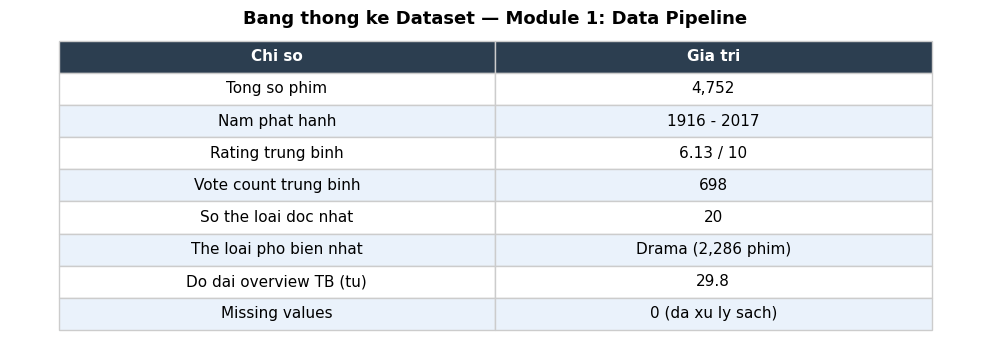

Da luu: ../output\01_dataset_stats_table.png

[Module 1] Da xuat 3 bieu do vao thu muc: C:\Users\ACER\OneDrive\Desktop\KhaiPha\output


In [17]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import pandas as pd

# Tao thu muc output neu chua co
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Thu muc output: {os.path.abspath(OUTPUT_DIR)}")

df = pd.read_csv("../data/processed/movies.csv")

# --------------------------------------------------
# Bieu do 1: Phan phoi the loai phim
# --------------------------------------------------
all_genres = []
for g in df['genres']:
    all_genres.extend(json.loads(g))

genre_counts = Counter(all_genres)
genres_sorted = sorted(genre_counts.items(), key=lambda x: -x[1])
g_labels = [x[0] for x in genres_sorted]
g_values = [x[1] for x in genres_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(g_labels[::-1], g_values[::-1], color='steelblue', edgecolor='white')
for bar, val in zip(bars, g_values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('So phim', fontsize=12)
ax.set_title(f'Phan phoi The loai Phim trong Dataset ({len(df):,} phim)', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(g_values) + 300)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "01_genre_distribution.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 2: Phan phoi Rating + So phim theo Nam
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['rating'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean = {df['rating'].mean():.2f}")
axes[0].set_xlabel('Rating', fontsize=11)
axes[0].set_ylabel('So phim', fontsize=11)
axes[0].set_title('Phan phoi Rating Phim', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

year_counts = df['year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 1970]
axes[1].bar(year_counts.index, year_counts.values, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Nam phat hanh', fontsize=11)
axes[1].set_ylabel('So phim', fontsize=11)
axes[1].set_title('So Phim theo Nam Phat hanh (1970-2017)', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "01_rating_and_year.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 3: Thong ke tong quat (bang so lieu)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

stats_data = [
    ['Chi so', 'Gia tri'],
    ['Tong so phim', f"{len(df):,}"],
    ['Nam phat hanh', f"{int(df['year'].min())} - {int(df['year'].max())}"],
    ['Rating trung binh', f"{df['rating'].mean():.2f} / 10"],
    ['Vote count trung binh', f"{df['vote_count'].mean():.0f}"],
    ['So the loai doc nhat', f"{len(set(all_genres))}"],
    ['The loai pho bien nhat', f"Drama ({genre_counts['Drama']:,} phim)"],
    ['Do dai overview TB (tu)', f"{df['overview_clean'].str.split().str.len().mean():.1f}"],
    ['Missing values', "0 (da xu ly sach)"],
]

table = ax.table(cellText=stats_data[1:], colLabels=stats_data[0],
                 cellLoc='center', loc='center', bbox=[0.05, 0, 0.9, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#eaf2fb')
    cell.set_edgecolor('#cccccc')
ax.set_title('Bang thong ke Dataset — Module 1: Data Pipeline', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "01_dataset_stats_table.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

print(f"\n[Module 1] Da xuat 3 bieu do vao thu muc: {os.path.abspath(OUTPUT_DIR)}")

## Xuất biểu đồ kết quả (Module 1)